# NVIDIA Developer Topic Modeling

This notebook builds a lightweight topic modeling layer for developer engagement behavior.

The goal is **not** to create a large new feature table. Instead, we treat each developer like a document and each activity / asset interaction like a token.

**Modeling idea:**

| NLP topic modeling concept | NVIDIA developer equivalent |
|---|---|
| Document | Developer |
| Word/token | Activity, SDK, asset, or engagement type |
| Topic | Latent developer ecosystem / behavior theme |
| Topic mixture | Developer's blended engagement profile |

Recommended first model: **TF-IDF + NMF** because it works well on sparse, non-negative behavioral count data and produces interpretable topics.


## 0. Setup

Update `DB_PATH` only if your DuckDB file has a different name. The notebook searches common table/column names so it is less likely to break if the table names changed slightly.


In [1]:
import re
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

DB_PATH = "developer_project.duckdb"
OUTPUT_DIR = Path("topic_model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Keep this intentionally modest so the first run is fast.
# Increase after the pipeline works end-to-end.
MAX_ACTIVITY_ROWS = 1_500_000
MAX_SDK_ROWS = 1_500_000
INCLUDE_SDK_DOWNLOADS = True
MAX_DEVELOPERS = 250_000
MIN_DEVELOPER_TOKENS = 2
MAX_TOKENS_PER_DEVELOPER_DOC = 200
RANDOM_STATE = 42

# Topic counts to compare. Start small, then tune based on interpretability.
K_GRID = [8, 10, 12, 14]
FINAL_N_TOPICS = 10

con = duckdb.connect(DB_PATH)
print("Connected to", DB_PATH)


Connected to developer_project.duckdb


## 1. Discover available tables and choose source tables

The model needs one activity-like table with a developer id and activity information. If SDK downloads are stored separately, the notebook can optionally include that too.


In [2]:
def list_tables(con):
    tables = con.execute("SHOW TABLES").fetchdf()
    if tables.empty:
        raise ValueError("No tables found in DuckDB database.")
    col = tables.columns[0]
    return tables[col].astype(str).tolist()


def get_columns(con, table_name):
    df = con.execute(f"DESCRIBE {table_name}").fetchdf()
    return df["column_name"].astype(str).tolist()


def find_first(cols, candidates):
    lookup = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lookup:
            return lookup[cand.lower()]
    return None


def score_activity_table(cols):
    lower = {c.lower() for c in cols}
    score = 0
    for c in ["dev_contact", "developer_id", "activity", "activity_name", "activity_type", "filepath", "activity_score", "activity_date"]:
        score += int(c in lower)
    return score

all_tables = list_tables(con)
print("Tables found:", all_tables)

candidate_rows = []
for t in all_tables:
    cols = get_columns(con, t)
    candidate_rows.append({"table": t, "n_cols": len(cols), "activity_score": score_activity_table(cols), "columns_preview": ", ".join(cols[:12])})

table_scan = pd.DataFrame(candidate_rows).sort_values("activity_score", ascending=False)
display(table_scan)

# Pick the strongest activity-like table automatically.
ACTIVITY_TABLE = table_scan.iloc[0]["table"]
activity_cols = get_columns(con, ACTIVITY_TABLE)
print("Selected activity table:", ACTIVITY_TABLE)
print(activity_cols)

Tables found: ['activity_base_v2', 'activity_dictionary_v2', 'activity_effort_mapping_ai_v2', 'activity_final', 'activity_labeled_v2', 'activity_ontology_v2', 'activity_raw', 'cluster_comparison_metrics_v1', 'cluster_label_map_feature_v1', 'cluster_label_map_v1', 'cluster_noise_sweep_v1', 'clustering_cohort_dormancy_active_v1', 'clustering_cohort_dormancy_cooling_v1', 'clustering_cohort_dormancy_dormant_v1', 'clustering_cohort_v1', 'clustering_cohort_v2_active', 'clustering_cohort_v2_cooling', 'clustering_cohort_v2_dormant', 'clustering_cohort_v3_active', 'clustering_cohort_v3_cooling', 'clustering_cohort_v3_dormant', 'clustering_cohort_v3_persona_active_cuda', 'clustering_cohort_v3_persona_active_genai', 'clustering_cohort_v3_persona_active_learning_community', 'clustering_cohort_v3_persona_active_robotics', 'clustering_cohort_v3_persona_active_simulation', 'clustering_cohort_v3_persona_active_unknown_or_other', 'clustering_cohort_v3_persona_cooling_cuda', 'clustering_cohort_v3_person

,table,n_cols,activity_score,columns_preview
0,activity_base_v2,12,7,"developer_id, activity_date, activity, activit..."
3,activity_final,16,7,"dev_contact, activity, activity_name, activity..."
4,activity_labeled_v2,40,7,"developer_id, activity_date, activity, activit..."
5,activity_ontology_v2,28,7,"developer_id, activity_date, activity, activit..."
6,activity_raw,16,7,"activity, activity_date, activity_name, activi..."
...,...,...,...,...
10,cluster_noise_sweep_v1,16,0,"experiment_id, experiment_type, space, cohort,..."
97,dev_lifecycle_cluster_run_stats_v8,10,0,"stratum, n_rows, n_features, features, n_clust..."
96,dev_lifecycle_cluster_run_stats_v11,11,0,"stratum, method, n_rows, n_features, features,..."
95,dev_lifecycle_cluster_run_stats_v10,11,0,"stratum, method, n_rows, n_features, features,..."


Selected activity table: activity_base_v2
['developer_id', 'activity_date', 'activity', 'activity_name', 'activity_type', 'activity_role', 'activity_attendance', 'activity_score', 'filepath', 'lead_source', 'lead_source_details', 'nvidia_campaign_id']


## 2. Build simple developer activity tokens

This is the only modeling representation we create:

- `activity::<activity>`
- `type::<activity_type>` when available
- `asset::<cleaned activity_name or filepath>` when available

This keeps the feature layer small and interpretable. We avoid adding dozens of numerical behavioral features here.


In [3]:
# Identify useful columns safely.
DEV_COL = find_first(activity_cols, ["dev_contact", "developer_id", "dev_id", "contact_id"])
ACTIVITY_COL = find_first(activity_cols, ["activity", "activity_category", "event_type"])
TYPE_COL = find_first(activity_cols, ["activity_type", "type"])
NAME_COL = find_first(activity_cols, ["activity_name", "name", "title"])
FILEPATH_COL = find_first(activity_cols, ["filepath", "file_path", "path"])
DATE_COL = find_first(activity_cols, ["activity_date", "date", "created_date"])
SCORE_COL = find_first(activity_cols, ["activity_score", "score"])

required = {"DEV_COL": DEV_COL, "ACTIVITY_COL": ACTIVITY_COL}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {activity_cols}")

print({
    "DEV_COL": DEV_COL,
    "ACTIVITY_COL": ACTIVITY_COL,
    "TYPE_COL": TYPE_COL,
    "NAME_COL": NAME_COL,
    "FILEPATH_COL": FILEPATH_COL,
    "DATE_COL": DATE_COL,
    "SCORE_COL": SCORE_COL,
})

select_parts = [f"CAST({DEV_COL} AS VARCHAR) AS developer_id", f"CAST({ACTIVITY_COL} AS VARCHAR) AS activity"]
if TYPE_COL:
    select_parts.append(f"CAST({TYPE_COL} AS VARCHAR) AS activity_type")
else:
    select_parts.append("CAST(NULL AS VARCHAR) AS activity_type")
if NAME_COL:
    select_parts.append(f"CAST({NAME_COL} AS VARCHAR) AS activity_name")
else:
    select_parts.append("CAST(NULL AS VARCHAR) AS activity_name")
if FILEPATH_COL:
    select_parts.append(f"CAST({FILEPATH_COL} AS VARCHAR) AS filepath")
else:
    select_parts.append("CAST(NULL AS VARCHAR) AS filepath")
if DATE_COL:
    select_parts.append(f"CAST({DATE_COL} AS DATE) AS activity_date")
else:
    select_parts.append("CAST(NULL AS DATE) AS activity_date")
if SCORE_COL:
    select_parts.append(f"TRY_CAST({SCORE_COL} AS DOUBLE) AS activity_score")
else:
    select_parts.append("CAST(1.0 AS DOUBLE) AS activity_score")

# Deterministic hash sample keeps the notebook runnable on large data.
query = f"""
WITH base AS (
    SELECT {', '.join(select_parts)}
    FROM {ACTIVITY_TABLE}
    WHERE {DEV_COL} IS NOT NULL
      AND {ACTIVITY_COL} IS NOT NULL
), sampled AS (
    SELECT *
    FROM base
    WHERE abs(hash(developer_id)) % 1000000 < 1000000
    LIMIT {MAX_ACTIVITY_ROWS}
)
SELECT * FROM sampled
"""

activity_df = con.execute(query).fetchdf()
print("Loaded activity rows:", len(activity_df))
display(activity_df.head())

{'DEV_COL': 'developer_id', 'ACTIVITY_COL': 'activity', 'TYPE_COL': 'activity_type', 'NAME_COL': 'activity_name', 'FILEPATH_COL': 'filepath', 'DATE_COL': 'activity_date', 'SCORE_COL': 'activity_score'}
Loaded activity rows: 1500000


,developer_id,activity,activity_type,activity_name,filepath,activity_date,activity_score
0,6417584,dli training,instructor-led,building rag agents with llms,None,2025-11-12,40.0
1,6752524,dli training,self-paced online,getting started with deep learning,None,2024-05-18,20.0
2,6389272,dli training,self-paced online,(course ending on 7/1/24) high-performance com...,None,2024-04-17,20.0
3,6763105,dli training,self-paced online,getting started with deep learning,None,2024-05-22,20.0
4,6790671,dli training,self-paced online,prompt engineering with llama-2 (access expire...,None,2024-05-30,20.0


In [4]:

STOP_TOKEN_VALUES = {
    "", "none", "nan", "null", "unknown", "na", "n_a",
    "2020", "2021", "2022", "2023", "2024", "2025", "2026",
    "course", "online", "access", "expires", "expire", "ending",
}


def clean_token_value(x, max_words=6):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if not s or s in STOP_TOKEN_VALUES:
        return None
    # Keep final filepath component if it looks like a path.
    s = s.split("?")[0]
    s = s.replace("\\", "/")
    if "/" in s:
        parts = [p for p in s.split("/") if p]
        if parts:
            s = parts[-1]
    s = re.sub(r"\.[a-z0-9]{1,6}$", "", s)
    s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
    if not s or s in STOP_TOKEN_VALUES:
        return None
    words = [w for w in s.split("_") if w and w not in STOP_TOKEN_VALUES]
    if not words:
        return None
    return "_".join(words[:max_words])


def make_activity_tokens(row):
    tokens = []
    activity = clean_token_value(row.get("activity"), max_words=5)
    if activity:
        tokens.append(f"activity__{activity}")
    activity_type = clean_token_value(row.get("activity_type"), max_words=5)
    if activity_type:
        tokens.append(f"type__{activity_type}")
    # Prefer filepath when present because it is often more specific for download behavior.
    asset_raw = row.get("filepath") if pd.notna(row.get("filepath")) else row.get("activity_name")
    asset = clean_token_value(asset_raw, max_words=7)
    if asset:
        tokens.append(f"asset__{asset}")
    return tokens

# Expand row-level activity interactions into developer-token pairs.
activity_records = []
for row in activity_df.to_dict("records"):
    dev = row["developer_id"]
    for token in make_activity_tokens(row):
        activity_records.append((dev, token, "activity"))

activity_token = pd.DataFrame(activity_records, columns=["developer_id", "token", "token_source"])
print("Activity token rows:", len(activity_token))
display(activity_token.head())


Activity token rows: 4412607


,developer_id,token,token_source
0,6417584,activity__dli_training,activity
1,6417584,type__instructor_led,activity
2,6417584,asset__building_rag_agents_with_llms,activity
3,6752524,activity__dli_training,activity
4,6752524,type__self_paced,activity


## 3. Add SDK download tokens

SDK downloads are added as lightweight tokens, not as a large feature table. This helps the topic model distinguish learning behavior from actual technology experimentation or adoption.

The notebook looks for `sdk_download_final` first, then falls back to another SDK-like table if needed. Useful tokens include:

- `sdk__<name>` for the downloaded SDK/package/product
- `sdk_source__<source>` for the channel such as PyPI, NGC, DevZone, DockerHub, GitHub, Conda, HuggingFace, or VSCode
- `sdk_category__<category>` for a compact semantic grouping such as inference, gpu_compute, robotics, data_science, simulation, or genai_llm


In [5]:

def score_sdk_table(cols):
    lower = {c.lower() for c in cols}
    score = 0
    for c in [
        "dev_contact", "developer_id", "contact_id",
        "sdk_name", "productname", "product_name", "source",
        "download_date", "activity_date", "created_date",
    ]:
        score += int(c in lower)
    return score


def infer_sdk_category(raw_name):
    name = clean_token_value(raw_name, max_words=12)
    if not name:
        return None
    patterns = [
        ("inference", ["tensorrt", "triton", "inference", "onnx", "deepstream"]),
        ("gpu_compute", ["cuda", "cudnn", "nccl", "cutlass", "nvcc"]),
        ("data_science", ["rapids", "cudf", "cuml", "dask", "riva", "merlin"]),
        ("robotics_edge", ["jetson", "isaac", "robot", "ros"]),
        ("simulation_omniverse", ["omniverse", "openusd", "usd", "physx", "modulus"]),
        ("genai_llm", ["nim", "nemo", "megatron", "llm", "rag", "transformer", "diffusion"]),
        ("computer_vision", ["vision", "opencv", "video", "image", "monai"]),
    ]
    for category, keywords in patterns:
        if any(k in name for k in keywords):
            return category
    return "other_sdk"


def make_sdk_tokens(row):
    tokens = []
    sdk_name = clean_token_value(row.get("sdk_name"), max_words=5)
    if sdk_name:
        tokens.append(f"sdk__{sdk_name}")
        category = infer_sdk_category(sdk_name)
        if category:
            tokens.append(f"sdk_category__{category}")
    source = clean_token_value(row.get("source"), max_words=4)
    if source:
        tokens.append(f"sdk_source__{source}")
    return tokens

sdk_token = pd.DataFrame(columns=["developer_id", "token", "token_source"])

if INCLUDE_SDK_DOWNLOADS:
    sdk_candidates = []
    for t in all_tables:
        cols = get_columns(con, t)
        s = score_sdk_table(cols)
        if "sdk" in t.lower() or s > 0:
            sdk_candidates.append({"table": t, "n_cols": len(cols), "sdk_score": s, "columns_preview": ", ".join(cols[:14])})

    sdk_scan = pd.DataFrame(sdk_candidates).sort_values(["sdk_score", "table"], ascending=[False, True])
    display(sdk_scan.head(15))

    preferred_sdk_tables = [t for t in ["sdk_download_final", "sdk_download_raw"] if t in all_tables]
    SDK_TABLE = preferred_sdk_tables[0] if preferred_sdk_tables else (sdk_scan.iloc[0]["table"] if not sdk_scan.empty else None)

    if SDK_TABLE is None:
        print("No SDK-like table found. Continuing with activity tokens only.")
    else:
        sdk_cols = get_columns(con, SDK_TABLE)
        print("Selected SDK table:", SDK_TABLE)
        print(sdk_cols)

        SDK_DEV_COL = find_first(sdk_cols, ["dev_contact", "developer_id", "dev_id", "contact_id"])
        SDK_NAME_COL = find_first(sdk_cols, ["sdk_name", "PRODUCTNAME", "productname", "product_name", "package_name", "asset_name", "name"])
        SDK_SOURCE_COL = find_first(sdk_cols, ["source", "download_source", "platform", "channel"])
        SDK_DATE_COL = find_first(sdk_cols, ["download_date", "activity_date", "created_date", "date"])

        print({
            "SDK_DEV_COL": SDK_DEV_COL,
            "SDK_NAME_COL": SDK_NAME_COL,
            "SDK_SOURCE_COL": SDK_SOURCE_COL,
            "SDK_DATE_COL": SDK_DATE_COL,
        })

        if SDK_DEV_COL is None or SDK_NAME_COL is None:
            print("SDK table is missing a developer id or SDK/product name column. Continuing with activity tokens only.")
        else:
            sdk_select_parts = [
                f"CAST({SDK_DEV_COL} AS VARCHAR) AS developer_id",
                f"CAST({SDK_NAME_COL} AS VARCHAR) AS sdk_name",
            ]
            if SDK_SOURCE_COL:
                sdk_select_parts.append(f"CAST({SDK_SOURCE_COL} AS VARCHAR) AS source")
            else:
                sdk_select_parts.append("CAST(NULL AS VARCHAR) AS source")
            if SDK_DATE_COL:
                sdk_select_parts.append(f"CAST({SDK_DATE_COL} AS DATE) AS download_date")
            else:
                sdk_select_parts.append("CAST(NULL AS DATE) AS download_date")

            sdk_query = f"""
            WITH base AS (
                SELECT {', '.join(sdk_select_parts)}
                FROM {SDK_TABLE}
                WHERE {SDK_DEV_COL} IS NOT NULL
                  AND {SDK_NAME_COL} IS NOT NULL
            ), sampled AS (
                SELECT *
                FROM base
                WHERE abs(hash(developer_id)) % 1000000 < 1000000
                LIMIT {MAX_SDK_ROWS}
            )
            SELECT * FROM sampled
            """
            sdk_df = con.execute(sdk_query).fetchdf()
            print("Loaded SDK rows:", len(sdk_df))
            display(sdk_df.head())

            sdk_records = []
            for row in sdk_df.to_dict("records"):
                dev = row["developer_id"]
                for token in make_sdk_tokens(row):
                    sdk_records.append((dev, token, "sdk"))

            sdk_token = pd.DataFrame(sdk_records, columns=["developer_id", "token", "token_source"])
            print("SDK token rows:", len(sdk_token))
            display(sdk_token.head())

# Combine activities and SDK downloads into one developer-token stream.
dev_token = pd.concat([activity_token, sdk_token], ignore_index=True)
print("Combined developer-token rows:", len(dev_token))
print(dev_token["token_source"].value_counts(dropna=False))
display(dev_token.head())


,table,n_cols,sdk_score,columns_preview
114,sdk_download_final,16,4,"source, sdk_name, product_name, product_releas..."
115,sdk_download_raw,16,3,"source, sdk_name, PRODUCTNAME, PRODUCTRELEASE,..."
0,activity_base_v2,12,2,"developer_id, activity_date, activity, activit..."
1,activity_final,16,2,"dev_contact, activity, activity_name, activity..."
2,activity_labeled_v2,40,2,"developer_id, activity_date, activity, activit..."
3,activity_ontology_v2,28,2,"developer_id, activity_date, activity, activit..."
4,activity_raw,16,2,"activity, activity_date, activity_name, activi..."
61,contact_final,32,2,"developer_id, program_application_source, coun..."
62,contact_one_row_v2,16,2,"developer_id, created_date, first_activity_dat..."
63,contact_raw,32,2,"developer_id, program_application_source, coun..."


Selected SDK table: sdk_download_final
['source', 'sdk_name', 'product_name', 'product_release', 'country', 'region', 'subregion', 'territory', 'zone', 'download_date', 'file_type', 'operating_system', 'os_distribution', 'architecture', 'kpi', 'download_count']
{'SDK_DEV_COL': None, 'SDK_NAME_COL': 'sdk_name', 'SDK_SOURCE_COL': 'source', 'SDK_DATE_COL': 'download_date'}
SDK table is missing a developer id or SDK/product name column. Continuing with activity tokens only.
Combined developer-token rows: 4412607
token_source
activity    4412607
Name: count, dtype: int64


,developer_id,token,token_source
0,6417584,activity__dli_training,activity
1,6417584,type__instructor_led,activity
2,6417584,asset__building_rag_agents_with_llms,activity
3,6752524,activity__dli_training,activity
4,6752524,type__self_paced,activity


## 4. Filter tokens and keep a manageable developer universe

This step removes very rare tokens and overly generic tokens, then keeps developers with at least a small amount of signal. The filtering is intentionally simple so the topic model stays explainable.


In [6]:

# Remove extremely rare tokens and extremely generic tokens.
token_counts = dev_token["token"].value_counts()
valid_tokens = token_counts[(token_counts >= 20) & (token_counts <= token_counts.quantile(0.990))].index
filtered = dev_token[dev_token["token"].isin(valid_tokens)].copy()

# Keep developers with at least a few tokens.
dev_counts = filtered.groupby("developer_id").size()
valid_devs = dev_counts[dev_counts >= MIN_DEVELOPER_TOKENS].index
filtered = filtered[filtered["developer_id"].isin(valid_devs)]

# Optional deterministic developer cap.
if filtered["developer_id"].nunique() > MAX_DEVELOPERS:
    dev_sample = (
        pd.Series(filtered["developer_id"].unique(), name="developer_id")
        .sample(n=MAX_DEVELOPERS, random_state=RANDOM_STATE)
    )
    filtered = filtered[filtered["developer_id"].isin(dev_sample)]

print("Filtered developer-token rows:", len(filtered))
print("Developers:", filtered["developer_id"].nunique())
print("Tokens:", filtered["token"].nunique())
print("Token sources after filtering:")
print(filtered["token_source"].value_counts(dropna=False))
display(filtered["token"].value_counts().head(30).reset_index().rename(columns={"index":"token", "token":"n"}))


Filtered developer-token rows: 567806
Developers: 175671
Tokens: 331
Token sources after filtering:
token_source
activity    567806
Name: count, dtype: int64


,n,count
0,asset__building_rag_agents_with_llms,37394
1,asset__getting_started_with_ai_on_jetson_nano,33894
2,asset__c,32231
3,asset__building_a_brain_in_10_minutes,31131
4,asset__getting_started_with_deep_learning,24729
5,asset__fundamentals_of_accelerated_computing_w...,23341
6,asset__building_transformer_based_natural_lang...,21968
7,asset__augment_your_llm_using_retrieval_augmen...,19427
8,asset__an_even_easier_introduction_to_cuda,18920
9,asset__disaster_risk_monitoring_using_satellit...,13997


## 5. Convert developers into documents

Each developer becomes a short token document. We cap repeated tokens so a single very active user does not dominate the model.


In [7]:
def cap_and_join(tokens, max_len=MAX_TOKENS_PER_DEVELOPER_DOC):
    # tokens arrive as a series; keep deterministic order after value counts
    vc = pd.Series(tokens).value_counts()
    expanded = []
    for token, n in vc.items():
        expanded.extend([token] * int(min(n, 10)))
    return " ".join(expanded[:max_len])

docs = (
    filtered.groupby("developer_id")["token"]
    .apply(cap_and_join)
    .reset_index(name="document")
)

print("Developer documents:", docs.shape)
display(docs.head())

Developer documents: (175671, 2)


,developer_id,document
0,10001119,asset__generative_ai_with_diffusion_models ass...
1,10002109,asset__exploring_adversarial_machine_learning ...
2,10002314,asset__augment_your_llm_using_retrieval_augmen...
3,1000477,asset__transferring_robot_learning_policies_fr...
4,10005813,asset__gpu_acceleration_with_the_c_standard_li...


## 6. Compare topic counts with TF-IDF + NMF

We compare a few topic counts using:

- reconstruction error: lower is better, but not enough by itself
- topic diversity: higher means topics use less repetitive top terms
- interpretability: manually inspect top tokens before finalizing


Count matrix: (175671, 329)
TF-IDF matrix: (175671, 329)


,n_topics,reconstruction_error,topic_diversity_top12
0,8,326.116825,0.604167
1,10,312.386888,0.558333
2,12,299.184448,0.513889
3,14,287.040131,0.464286


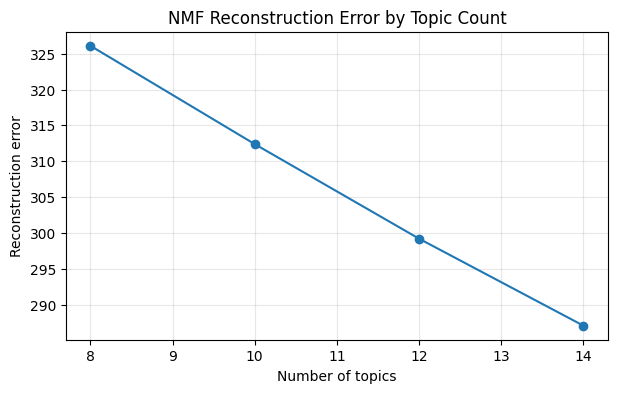

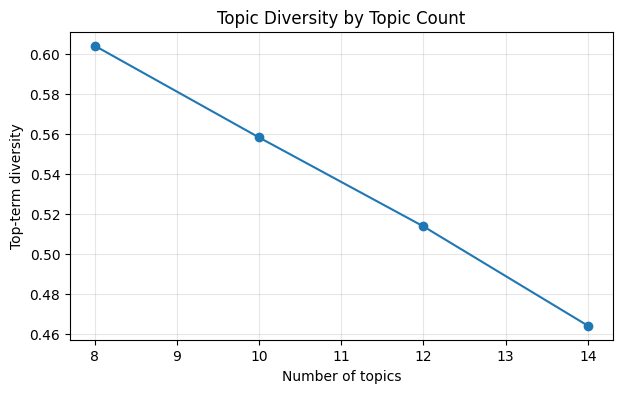

In [8]:
# CountVectorizer can use our already-clean token strings directly.
vectorizer = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    min_df=10,
    max_df=0.50,
)
counts = vectorizer.fit_transform(docs["document"])
terms = np.array(vectorizer.get_feature_names_out())
print("Count matrix:", counts.shape)

# TF-IDF downweights generic interactions and boosts distinctive engagement patterns.
tfidf = TfidfTransformer(norm="l2", sublinear_tf=True)
X = tfidf.fit_transform(counts)
print("TF-IDF matrix:", X.shape)


def topic_diversity(components, top_n=12):
    top_terms = []
    for comp in components:
        top_terms.extend(comp.argsort()[::-1][:top_n])
    return len(set(top_terms)) / len(top_terms)

results = []
models = {}
for k in K_GRID:
    nmf = NMF(
        n_components=k,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=400,
        beta_loss="frobenius",
        solver="cd",
        alpha_W=0.0001,
        alpha_H=0.0001,
        l1_ratio=0.15,
    )
    W = nmf.fit_transform(X)
    H = nmf.components_
    results.append({
        "n_topics": k,
        "reconstruction_error": nmf.reconstruction_err_,
        "topic_diversity_top12": topic_diversity(H, top_n=12),
    })
    models[k] = (nmf, W, H)

model_comparison = pd.DataFrame(results)
display(model_comparison)

plt.figure(figsize=(7, 4))
plt.plot(model_comparison["n_topics"], model_comparison["reconstruction_error"], marker="o")
plt.title("NMF Reconstruction Error by Topic Count")
plt.xlabel("Number of topics")
plt.ylabel("Reconstruction error")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(model_comparison["n_topics"], model_comparison["topic_diversity_top12"], marker="o")
plt.title("Topic Diversity by Topic Count")
plt.xlabel("Number of topics")
plt.ylabel("Top-term diversity")
plt.grid(True, alpha=0.3)
plt.show()


## 7. Fit final NMF topic model and inspect topics

Rename the topic labels after reviewing the top tokens. For example, a topic dominated by `tensorrt`, `triton`, `ngc`, and `cuda` might be labeled **Production AI Deployment**.


In [9]:
FINAL_N_TOPICS = FINAL_N_TOPICS
nmf, W, H = models.get(FINAL_N_TOPICS, (None, None, None))
if nmf is None:
    nmf = NMF(n_components=FINAL_N_TOPICS, init="nndsvda", random_state=RANDOM_STATE, max_iter=400, alpha_W=0.0001, alpha_H=0.0001, l1_ratio=0.15)
    W = nmf.fit_transform(X)
    H = nmf.components_

# Normalize developer topic weights to proportions for interpretation.
W_prop = normalize(W, norm="l1", axis=1)

def top_terms_for_topic(topic_idx, n=15):
    weights = H[topic_idx]
    idx = weights.argsort()[::-1][:n]
    return pd.DataFrame({
        "topic": topic_idx,
        "term": terms[idx],
        "weight": weights[idx],
    })

topic_terms = pd.concat([top_terms_for_topic(i, n=20) for i in range(FINAL_N_TOPICS)], ignore_index=True)
display(topic_terms.groupby("topic").head(12))

# Wide topic-term view for easier reading.
topic_summary = []
for i in range(FINAL_N_TOPICS):
    top = topic_terms[topic_terms["topic"] == i].head(12)
    topic_summary.append({
        "topic": i,
        "suggested_label": "RENAME_ME",
        "top_terms": ", ".join(top["term"].tolist())
    })
topic_summary = pd.DataFrame(topic_summary)
display(topic_summary)


,topic,term,weight
0,0,asset__building_rag_agents_with_llms,1.853305
1,0,asset__augment_your_llm_using_retrieval_augmen...,1.467544
2,0,asset__accelerate_data_science_workflows_with_...,0.218336
3,0,asset__building_llm_applications_with_prompt_e...,0.195735
4,0,asset__introduction_to_nvidia_nim_microservices,0.159123
...,...,...,...
187,9,asset__rapid_application_development_with_larg...,0.068132
188,9,asset__exploring_adversarial_machine_learning,0.064246
189,9,asset__deploying_a_model_for_inference_at_prod...,0.061662
190,9,asset__sizing_llm_inference_systems,0.055128


,topic,suggested_label,top_terms
0,0,RENAME_ME,"asset__building_rag_agents_with_llms, asset__a..."
1,1,RENAME_ME,"asset__c, asset__26_accelerating_cuda_c_applic..."
2,2,RENAME_ME,"asset__getting_started_with_ai_on_jetson_nano,..."
3,3,RENAME_ME,"asset__getting_started_with_deep_learning, ass..."
4,4,RENAME_ME,asset__building_transformer_based_natural_lang...
5,5,RENAME_ME,asset__fundamentals_of_accelerated_computing_w...
6,6,RENAME_ME,"asset__building_a_brain_in_10_minutes, asset__..."
7,7,RENAME_ME,"asset__an_even_easier_introduction_to_cuda, as..."
8,8,RENAME_ME,asset__fundamentals_of_deep_learning_for_compu...
9,9,RENAME_ME,"asset__generative_ai_with_diffusion_models, as..."


## 8. Assign each developer a topic profile

This produces a compact developer-level output:

- dominant topic
- topic strength
- topic mixture columns

This can be joined back to the final developer profile table if needed.


In [10]:
topic_cols = [f"topic_{i}_score" for i in range(FINAL_N_TOPICS)]
dev_topics = pd.concat([
    docs[["developer_id"]].reset_index(drop=True),
    pd.DataFrame(W_prop, columns=topic_cols)
], axis=1)

dev_topics["dominant_topic"] = W_prop.argmax(axis=1)
dev_topics["dominant_topic_score"] = W_prop.max(axis=1)
dev_topics["topic_entropy"] = -(W_prop * np.log(W_prop + 1e-12)).sum(axis=1)

# Lower entropy means more specialized. Higher entropy means broader/hybrid behavior.
display(dev_topics.head())

display(
    dev_topics.groupby("dominant_topic")
    .agg(n_developers=("developer_id", "count"), avg_strength=("dominant_topic_score", "mean"), avg_entropy=("topic_entropy", "mean"))
    .reset_index()
    .sort_values("n_developers", ascending=False)
)

,developer_id,topic_0_score,topic_1_score,topic_2_score,topic_3_score,topic_4_score,topic_5_score,topic_6_score,topic_7_score,topic_8_score,topic_9_score,dominant_topic,dominant_topic_score,topic_entropy
0,10001119,0.000000,0.000000,0.000000,0.048455,0.0,0.000000,0.0,0.000000,0.000000,0.951545,9,0.951545,0.193939
1,10002109,0.006343,0.000000,0.000000,0.963927,0.0,0.000000,0.0,0.000000,0.000000,0.029729,3,0.963927,0.172031
2,10002314,0.184268,0.000000,0.000000,0.342307,0.0,0.000000,0.0,0.000000,0.000000,0.473425,9,0.473425,1.032642
3,1000477,0.000000,0.000000,0.554887,0.000000,0.0,0.000000,0.0,0.019931,0.425182,0.000000,2,0.554887,0.768493
4,10005813,0.093986,0.049246,0.000000,0.201910,0.0,0.042604,0.0,0.200607,0.000000,0.411647,9,0.411647,1.515638


,dominant_topic,n_developers,avg_strength,avg_entropy
0,0,28194,0.640958,0.479027
7,7,25804,0.604899,0.901621
9,9,23442,0.589944,0.915806
2,2,17741,0.743183,0.545774
3,3,16812,0.713026,0.633959
6,6,15781,0.713659,0.656834
4,4,15510,0.766701,0.504145
1,1,12510,0.892824,0.255903
5,5,12433,0.731952,0.521997
8,8,7444,0.907448,0.193654


## 9. Visualize topic structure

The first plot shows how common each dominant topic is. The second is a 2D projection of developer topic profiles. Because we are not adding lots of features, the projection is based only on topic proportions.


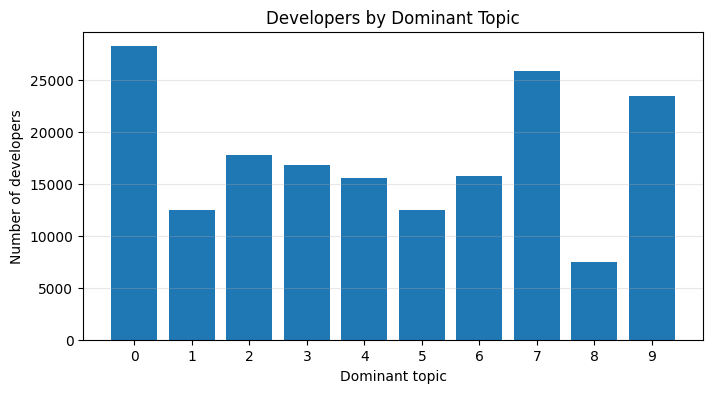

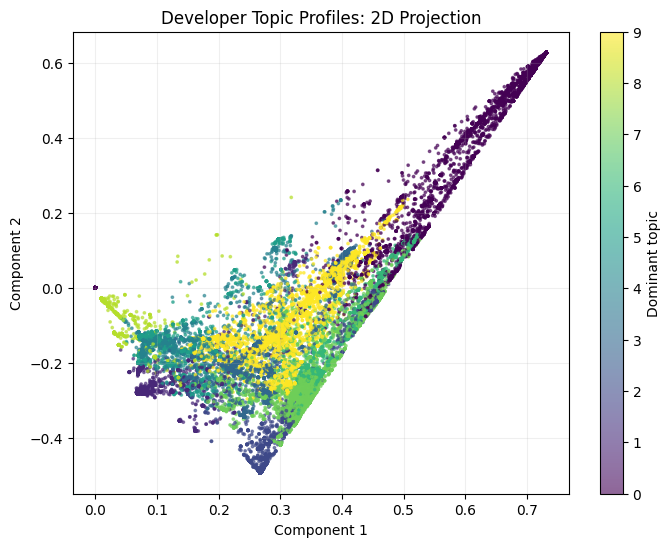

In [11]:
topic_counts = dev_topics["dominant_topic"].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.title("Developers by Dominant Topic")
plt.xlabel("Dominant topic")
plt.ylabel("Number of developers")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Simple 2D projection of topic profile. This avoids requiring UMAP.
if FINAL_N_TOPICS >= 3:
    projector = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
    coords = projector.fit_transform(W_prop)
else:
    coords = W_prop[:, :2]

viz = dev_topics[["developer_id", "dominant_topic", "dominant_topic_score", "topic_entropy"]].copy()
viz["x"] = coords[:, 0]
viz["y"] = coords[:, 1]

# Sample for plotting readability.
plot_viz = viz.sample(n=min(50_000, len(viz)), random_state=RANDOM_STATE)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(plot_viz["x"], plot_viz["y"], c=plot_viz["dominant_topic"], s=3, alpha=0.6)
plt.title("Developer Topic Profiles: 2D Projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(scatter, label="Dominant topic")
plt.grid(True, alpha=0.2)
plt.show()

## 10. Export outputs

These files are intentionally small and useful for handoff:

- `developer_topic_scores.csv`: developer-level topic mixture
- `topic_terms.csv`: top terms per topic
- `topic_summary_template.csv`: manual labeling template
- `model_comparison.csv`: quick tuning comparison


In [12]:
dev_topics.to_csv(OUTPUT_DIR / "developer_topic_scores.csv", index=False)
topic_terms.to_csv(OUTPUT_DIR / "topic_terms.csv", index=False)
topic_summary.to_csv(OUTPUT_DIR / "topic_summary_template.csv", index=False)
model_comparison.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
filtered["token"].value_counts().reset_index().rename(columns={"index": "token", "token": "n"}).to_csv(OUTPUT_DIR / "token_counts_used.csv", index=False)
filtered.groupby(["token_source", "token"]).size().reset_index(name="n").to_csv(OUTPUT_DIR / "token_source_counts_used.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)


Saved outputs to: /Users/navsanya/Desktop/Spring2026_IndustryProject/topic_model_outputs
- developer_topic_scores.csv
- model_comparison.csv
- token_counts_used.csv
- token_source_counts_used.csv
- topic_summary_template.csv
- topic_terms.csv


In [13]:
con.close()